# 🎬 Movie Recommendation System

A complete **content-based movie recommendation system** using the TMDB 5000 Movies dataset.

### Project workflow
1. Import libraries
2. Load and validate the TMDB datasets
3. Clean and parse genres, keywords, cast, and crew metadata
4. Build a combined text representation
5. Convert text into TF-IDF vectors
6. Calculate cosine similarity
7. Build a robust recommendation function
8. Test recommendations
9. Add exploratory analysis and visualization
10. Save the prepared recommendation data for reuse

> **Recommendation method:** content-based filtering. Movies are recommended because their available metadata is similar to the selected movie.


## 1. Import Libraries

In [1]:
import ast
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

This project expects these two files in the same folder as the notebook:

- `tmdb_5000_movies.csv`
- `tmdb_5000_credits.csv`

The files can be obtained from the **TMDB 5000 Movie Dataset** on Kaggle.


In [2]:
MOVIES_FILE = "/content/tmdb_5000_movies.csv"
CREDITS_FILE = "/content/tmdb_5000_credits.csv"

if not os.path.exists(MOVIES_FILE) or not os.path.exists(CREDITS_FILE):
    raise FileNotFoundError(
        "Dataset files not found. Put 'tmdb_5000_movies.csv' and "
        "'tmdb_5000_credits.csv' in the notebook's working directory."
    )

movies_raw = pd.read_csv(MOVIES_FILE)
credits_raw = pd.read_csv(CREDITS_FILE)

print(f"Movies dataset shape:  {movies_raw.shape}")
print(f"Credits dataset shape: {credits_raw.shape}")

display(movies_raw.head(3))


Movies dataset shape:  (4803, 20)
Credits dataset shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 878, ""name"": ""...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""space war""}, {""id"": 33...",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn bet...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Twentieth Century Fox Film Corporation"", ""id"": 306}, {""na...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}, {""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""name"": ""Action""}]",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug abuse""}, {""id"": 911, ""name"": ""exotic island""}, {""id"": 1319,...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will T...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""Jerry Bruckheimer Films"", ""id"": 130}, {""name"": ""Second Mate Pr...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 80, ""name"": ""Crime""}]",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name"": ""based on novel""}, {""id"": 4289, ""name"": ""secret agent""}, {""id"": 966...",en,Spectre,A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles politica...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""name"": ""Danjaq"", ""id"": 10761}, {""name"": ""B24"", ""id"": 69434}]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}, {""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}, {""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""...",Released,A Plan No One Escapes,Spectre,6.3,4466


## 3. Merge and Inspect the Datasets

In [3]:
# The credits file uses the movie title as its join key.
movies = movies_raw.merge(
    credits_raw,
    left_on="title",
    right_on="title",
    how="inner",
    suffixes=("", "_credits")
)

print("Merged dataset shape:", movies.shape)
print("\nMissing values in key columns:")
display(movies[["title", "overview", "genres", "keywords", "cast", "crew"]].isna().sum())

display(movies[["title", "release_date", "vote_average", "vote_count"]].head())


Merged dataset shape: (4809, 23)

Missing values in key columns:


,0
title,0
overview,3
genres,0
keywords,0
cast,0
crew,0


,title,release_date,vote_average,vote_count
0,Avatar,2009-12-10,7.2,11800
1,Pirates of the Caribbean: At World's End,2007-05-19,6.9,4500
2,Spectre,2015-10-26,6.3,4466
3,The Dark Knight Rises,2012-07-16,7.6,9106
4,John Carter,2012-03-07,6.1,2124


## 4. Select Relevant Features

In [4]:
# Keep the fields used by the recommendation engine.
# We also retain rating information for optional exploratory analysis.
required_columns = [
    "title", "overview", "genres", "keywords", "cast", "crew",
    "release_date", "vote_average", "vote_count", "popularity"
]

movies = movies[[col for col in required_columns if col in movies.columns]].copy()

# Remove exact duplicate titles if any exist.
movies = movies.drop_duplicates(subset="title").reset_index(drop=True)

print("Movies available for recommendation:", len(movies))
display(movies.head(3))


Movies available for recommendation: 4800


,title,overview,genres,keywords,cast,crew,release_date,vote_average,vote_count,popularity
0,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn bet...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 878, ""name"": ""...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""space war""}, {""id"": 33...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""credit_id"": ""5602a8a7c3a3685532001c9a"", ""gender"": 2, ""id"": 65731, ""nam...","[{""credit_id"": ""52fe48009251416c750aca23"", ""department"": ""Editing"", ""gender"": 0, ""id"": 1721, ""job"": ""Editor"", ""name""...",2009-12-10,7.2,11800,150.437577
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will T...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""name"": ""Action""}]","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug abuse""}, {""id"": 911, ""name"": ""exotic island""}, {""id"": 1319,...","[{""cast_id"": 4, ""character"": ""Captain Jack Sparrow"", ""credit_id"": ""52fe4232c3a36847f800b50d"", ""gender"": 2, ""id"": 85,...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""department"": ""Camera"", ""gender"": 2, ""id"": 120, ""job"": ""Director of Photo...",2007-05-19,6.9,4500,139.082615
2,Spectre,A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles politica...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 80, ""name"": ""Crime""}]","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name"": ""based on novel""}, {""id"": 4289, ""name"": ""secret agent""}, {""id"": 966...","[{""cast_id"": 1, ""character"": ""James Bond"", ""credit_id"": ""52fe4d22c3a368484e1d8d6b"", ""gender"": 2, ""id"": 8784, ""name"":...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""department"": ""Sound"", ""gender"": 2, ""id"": 153, ""job"": ""Original Music Com...",2015-10-26,6.3,4466,107.376788


## 5. Parse TMDB Metadata

The `genres`, `keywords`, `cast`, and `crew` columns are stored as Python-list-like strings.

We convert those values into useful words:
- genres → all genre names
- keywords → all keyword names
- cast → top 5 billed actors
- crew → director name

Using these fields makes the content representation substantially richer than using only the movie overview.


In [5]:
def parse_list_names(value, limit=None):
    """Extract the 'name' field from a TMDB JSON/list-like string."""
    if pd.isna(value) or value == "":
        return []

    try:
        data = ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError):
        return []

    if not isinstance(data, list):
        return []

    names = []
    for item in data[:limit] if limit else data:
        if isinstance(item, dict) and item.get("name"):
            names.append(str(item["name"]).strip().lower().replace(" ", "_"))

    return names


def get_director(value):
    """Extract the director from TMDB crew metadata."""
    if pd.isna(value) or value == "":
        return ""

    try:
        data = ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError):
        return ""

    if not isinstance(data, list):
        return ""

    for item in data:
        if (
            isinstance(item, dict)
            and item.get("job") == "Director"
            and item.get("name")
        ):
            return str(item["name"]).strip().lower().replace(" ", "_")

    return ""


movies["genres"] = movies["genres"].apply(parse_list_names)
movies["keywords"] = movies["keywords"].apply(parse_list_names)
movies["cast"] = movies["cast"].apply(lambda x: parse_list_names(x, limit=5))
movies["director"] = movies["crew"].apply(get_director)

display(movies[["title", "genres", "keywords", "cast", "director"]].head(5))


,title,genres,keywords,cast,director
0,Avatar,"[action, adventure, fantasy, science_fiction]","[culture_clash, future, space_war, space_colony, society, space_travel, futuristic, romance, space, alien, tribe, al...","[sam_worthington, zoe_saldana, sigourney_weaver, stephen_lang, michelle_rodriguez]",james_cameron
1,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drug_abuse, exotic_island, east_india_trading_company, love_of_one's_life, traitor, shipwreck, strong_woman,...","[johnny_depp, orlando_bloom, keira_knightley, stellan_skarsgård, chow_yun-fat]",gore_verbinski
2,Spectre,"[action, adventure, crime]","[spy, based_on_novel, secret_agent, sequel, mi6, british_secret_service, united_kingdom]","[daniel_craig, christoph_waltz, léa_seydoux, ralph_fiennes, monica_bellucci]",sam_mendes
3,The Dark Knight Rises,"[action, crime, drama, thriller]","[dc_comics, crime_fighter, terrorist, secret_identity, burglar, hostage_drama, time_bomb, gotham_city, vigilante, co...","[christian_bale, michael_caine, gary_oldman, anne_hathaway, tom_hardy]",christopher_nolan
4,John Carter,"[action, adventure, science_fiction]","[based_on_novel, mars, medallion, space_travel, princess, alien, steampunk, martian, escape, edgar_rice_burroughs, a...","[taylor_kitsch, lynn_collins, samantha_morton, willem_dafoe, thomas_haden_church]",andrew_stanton


## 6. Clean and Combine Features

In [6]:
def clean_text(value):
    """Normalize free text while preserving meaningful words."""
    if pd.isna(value):
        return ""
    value = str(value).lower()
    value = re.sub(r"[^a-z0-9\s_]", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


def combine_features(row):
    overview = clean_text(row["overview"])
    genres = " ".join(row["genres"])
    keywords = " ".join(row["keywords"])
    cast = " ".join(row["cast"])
    director = row["director"]

    # Repeating metadata words slightly increases their influence in TF-IDF.
    return " ".join([
        overview,
        genres,
        keywords,
        cast,
        director,
        director
    ]).strip()


movies["combined_features"] = movies.apply(combine_features, axis=1)

# A movie without any usable text cannot produce meaningful recommendations.
movies = movies[movies["combined_features"].str.len() > 0].reset_index(drop=True)

print("Movies with usable recommendation metadata:", len(movies))
display(movies[["title", "combined_features"]].head(3))


Movies with usable recommendation metadata: 4800


,title,combined_features
0,Avatar,in the 22nd century a paraplegic marine is dispatched to the moon pandora on a unique mission but becomes torn betwe...
1,Pirates of the Caribbean: At World's End,captain barbossa long believed to be dead has come back to life and is headed to the edge of the earth with will tur...
2,Spectre,a cryptic message from bond s past sends him on a trail to uncover a sinister organization while m battles political...


## 7. Convert Text to TF-IDF Vectors

In [7]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2),
    min_df=1
)

feature_vectors = vectorizer.fit_transform(movies["combined_features"])

print("TF-IDF matrix shape:", feature_vectors.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))


TF-IDF matrix shape: (4800, 50000)
Vocabulary size: 50000


## 8. Calculate Cosine Similarity

In [8]:
# Cosine similarity measures how close two movie content vectors are.
similarity = cosine_similarity(feature_vectors)

print("Similarity matrix shape:", similarity.shape)


Similarity matrix shape: (4800, 4800)


## 9. Build the Recommendation Engine

The function below:
- accepts a movie title,
- performs case-insensitive matching,
- suggests close title matches if the exact title is not found,
- returns the requested number of recommendations,
- excludes the selected movie itself,
- includes similarity scores,
- and optionally displays extra movie information.


In [9]:
# Normalized title lookup makes user input more forgiving.
movies["_title_key"] = movies["title"].str.lower().str.strip()
title_to_index = dict(zip(movies["_title_key"], movies.index))


def recommend(movie_name, n=10, min_score=0.0, show_details=True):
    """Return content-based movie recommendations.

    Parameters
    ----------
    movie_name : str
        Title of the movie used as the reference.
    n : int
        Number of recommendations.
    min_score : float
        Optional minimum cosine-similarity threshold.
    show_details : bool
        If True, display the recommendations.

    Returns
    -------
    pandas.DataFrame
        Recommended movies with similarity scores.
    """
    if not isinstance(movie_name, str) or not movie_name.strip():
        raise ValueError("Please provide a non-empty movie title.")

    if n < 1:
        raise ValueError("n must be at least 1.")

    query = movie_name.lower().strip()

    if query not in title_to_index:
        # Provide useful title suggestions instead of crashing.
        matches = movies[movies["_title_key"].str.contains(query, regex=False, na=False)]
        if matches.empty:
            raise ValueError(
                f"Movie '{movie_name}' was not found. "
                "Try a different title or inspect movies['title'].head()."
            )
        print("Exact title not found. Possible matches:")
        display(matches[["title"]].head(10))
        return pd.DataFrame()

    index = title_to_index[query]
    distances = similarity[index]

    candidates = [
        (i, float(score))
        for i, score in enumerate(distances)
        if i != index and score >= min_score
    ]

    candidates.sort(key=lambda x: x[1], reverse=True)
    candidates = candidates[:n]

    result = movies.iloc[[i for i, _ in candidates]].copy()
    result["similarity_score"] = [score for _, score in candidates]

    columns = [
        col for col in [
            "title", "release_date", "vote_average",
            "vote_count", "popularity", "genres", "similarity_score"
        ] if col in result.columns
    ]

    result = result[columns].reset_index(drop=True)

    if show_details:
        display(result)

    return result


## 10. Test the Recommendation System

In [10]:
# Example 1
avatar_recommendations = recommend("Avatar", n=10)


,title,release_date,vote_average,vote_count,popularity,genres,similarity_score
0,Aliens,1986-07-18,7.7,3220,67.660940,"[horror, action, thriller, science_fiction]",0.151720
1,True Lies,1994-07-14,6.8,1116,38.729418,"[action, thriller]",0.111952
2,Terminator 2: Judgment Day,1991-07-01,7.7,4185,101.741550,"[action, thriller, science_fiction]",0.105722
3,The Terminator,1984-10-26,7.3,4128,74.234793,"[action, thriller, science_fiction]",0.098438
4,The Abyss,1989-08-09,7.1,808,24.961625,"[adventure, action, thriller, science_fiction]",0.093272
5,Titan A.E.,2000-06-16,6.3,313,14.443810,"[animation, action, science_fiction, family, adventure]",0.091095
6,Star Trek Into Darkness,2013-05-05,7.4,4418,78.291018,"[action, adventure, science_fiction]",0.089800
7,Falcon Rising,2014-09-05,5.5,71,6.988357,"[adventure, action]",0.086775
8,The Inhabited Island,2008-12-18,5.3,23,2.785832,"[action, fantasy, science_fiction, thriller]",0.086689
9,Apollo 18,2011-07-20,5.0,356,17.028252,"[horror, thriller, science_fiction]",0.077080


In [11]:
# Example 2
# Change this title to any movie available in the dataset.
inception_recommendations = recommend("Inception", n=10)


,title,release_date,vote_average,vote_count,popularity,genres,similarity_score
0,Don Jon,2013-07-26,5.9,1671,33.296684,"[romance, comedy, drama]",0.147176
1,Insomnia,2002-05-24,6.8,1148,41.322708,"[crime, mystery, thriller]",0.115200
2,The Prestige,2006-10-19,8.0,4391,74.440708,"[drama, mystery, thriller]",0.114504
3,Cypher,2002-10-01,6.7,192,11.636883,"[thriller, science_fiction, mystery]",0.100374
4,Memento,2000-10-11,8.1,4028,60.715151,"[mystery, thriller]",0.090085
5,Batman Begins,2005-06-10,7.5,7359,115.040024,"[action, crime, drama]",0.084689
6,Interstellar,2014-11-05,8.1,10867,724.247784,"[adventure, drama, science_fiction]",0.084422
7,The Dark Knight Rises,2012-07-16,7.6,9106,112.312950,"[action, crime, drama, thriller]",0.079720
8,Looper,2012-09-26,6.6,4697,46.377628,"[action, thriller, science_fiction]",0.074623
9,The Dark Knight,2008-07-16,8.2,12002,187.322927,"[drama, action, crime, thriller]",0.074542


## 11. Explore the Dataset

In [12]:
# Basic descriptive statistics
print("Number of movies:", len(movies))
print("Average vote:", round(movies["vote_average"].mean(), 2))
print("Average popularity:", round(movies["popularity"].mean(), 2))

print("\nTop 10 most popular movies:")
display(
    movies[["title", "popularity", "vote_average", "vote_count"]]
    .sort_values("popularity", ascending=False)
    .head(10)
)


Number of movies: 4800
Average vote: 6.09
Average popularity: 21.5

Top 10 most popular movies:


,title,popularity,vote_average,vote_count
546,Minions,875.581305,6.4,4571
95,Interstellar,724.247784,8.1,10867
788,Deadpool,514.569956,7.4,10995
94,Guardians of the Galaxy,481.098624,7.9,9742
127,Mad Max: Fury Road,434.278564,7.2,9427
28,Jurassic World,418.708552,6.5,8662
199,Pirates of the Caribbean: The Curse of the Black Pearl,271.972889,7.5,6985
82,Dawn of the Planet of the Apes,243.791743,7.3,4410
200,The Hunger Games: Mockingjay - Part 1,206.227151,6.6,5584
88,Big Hero 6,203.734590,7.8,6135


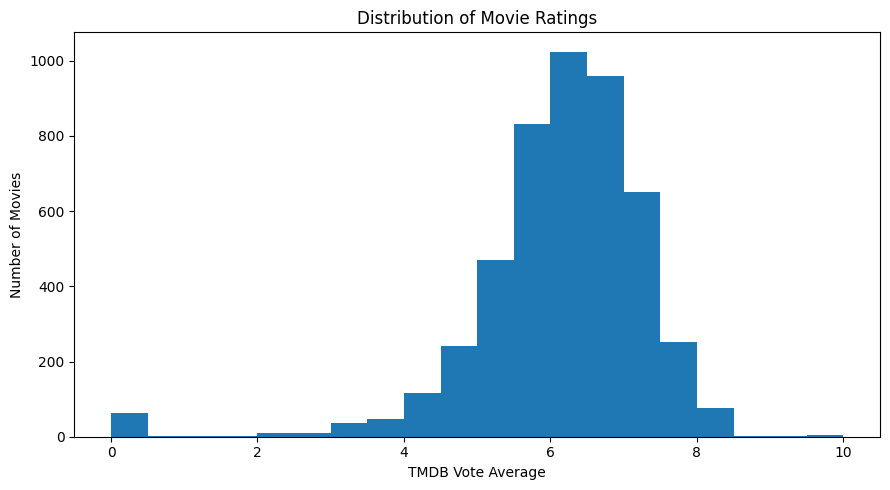

In [13]:
# Distribution of ratings
plt.figure(figsize=(9, 5))
plt.hist(movies["vote_average"].dropna(), bins=20)
plt.title("Distribution of Movie Ratings")
plt.xlabel("TMDB Vote Average")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()


## 12. Search the Dataset

This helper is useful when you know only part of a movie title.


In [14]:
def search_movies(keyword, limit=20):
    """Search movie titles by a partial, case-insensitive keyword."""
    keyword = str(keyword).strip().lower()

    if not keyword:
        return pd.DataFrame(columns=["title"])

    result = movies[
        movies["_title_key"].str.contains(keyword, regex=False, na=False)
    ][["title", "release_date", "vote_average", "popularity"]]

    return result.head(limit).reset_index(drop=True)


display(search_movies("dark"))


,title,release_date,vote_average,popularity
0,The Dark Knight Rises,2012-07-16,7.6,112.312950
1,Star Trek Into Darkness,2013-05-05,7.4,78.291018
2,Transformers: Dark of the Moon,2011-06-28,6.1,28.529607
3,The Dark Knight,2008-07-16,8.2,187.322927
4,Thor: The Dark World,2013-10-29,6.8,99.499595
5,Dark Shadows,2012-05-08,5.7,50.306728
6,Under Siege 2: Dark Territory,1995-07-13,5.6,13.080725
7,Edge of Darkness,2010-01-29,6.2,24.657931
8,Dark Water,2005-06-27,5.3,14.376463
9,The Ghost and the Darkness,1996-10-11,6.4,12.465250


## 13. Save Prepared Data

The model can be rebuilt quickly from the saved prepared dataset without repeating the metadata parsing step.


In [15]:
OUTPUT_FILE = "movie_recommendation_data.csv"

# Save human-readable/prepared features.
save_columns = [
    col for col in [
        "title", "overview", "genres", "keywords", "cast",
        "director", "release_date", "vote_average", "vote_count",
        "popularity", "combined_features"
    ] if col in movies.columns
]

movies[save_columns].to_csv(OUTPUT_FILE, index=False)

print(f"Prepared movie data saved to: {OUTPUT_FILE}")


Prepared movie data saved to: movie_recommendation_data.csv


## 14. Project Summary

### Technique used
**Content-Based Filtering**

### Main components
- **TF-IDF:** converts movie metadata into numerical feature vectors.
- **Cosine similarity:** measures similarity between movie vectors.
- **Metadata:** overview, genres, keywords, top cast, and director.
- **Recommendation:** returns movies with the highest similarity to the selected movie.

### Advantages
- Does not require user ratings or a user history.
- Can recommend movies for new users immediately.
- Recommendations are explainable through shared movie content.

### Limitations
- Recommendations depend on the quality and completeness of TMDB metadata.
- Similarity is based on content, not personal taste.
- Popularity, ratings, and collaborative user behavior are not directly used to choose recommendations.

### Future improvements
1. Add collaborative filtering using user ratings.
2. Build a Streamlit/Flask web interface.
3. Add poster images using TMDB's API.
4. Cache the TF-IDF matrix and similarity model.
5. Combine content similarity with popularity or rating-based ranking.
6. Add recommendation explanations such as “shared genre,” “same director,” or “similar keywords.”
